In [1]:
!pip install xgboost

In [2]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
import xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\TECHCRUSH DATA SCIENCE COHORT 5-20260313T165341Z-3-001\TECHCRUSH DATA SCIENCE COHORT 5\DATASETS\training (1).csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:


df["FraudResult"].value_counts() # imbalance

FraudResult
0    95469
1      193
Name: count, dtype: int64

In [5]:
df.isna().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  str                
 1   BatchId               95662 non-null  str                
 2   AccountId             95662 non-null  str                
 3   SubscriptionId        95662 non-null  str                
 4   CustomerId            95662 non-null  str                
 5   CurrencyCode          95662 non-null  str                
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  str                
 8   ProductId             95662 non-null  str                
 9   ProductCategory       95662 non-null  str                
 10  ChannelId             95662 non-null  str                
 11  Amount                95662 non-null  float64            
 12  Value          

# Feature Engineering

In [9]:
# This involves engineering new features to the data

In [10]:
df["Month"] = df["TransactionStartTime"].dt.month

In [11]:
df["Day"] = df["TransactionStartTime"].dt.day

In [12]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,Month,Day
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,11,15
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,11,15
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,11,15
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,11,15
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,11,15


In [13]:
def credit_or_debit(row):
    if row < 0:
        return 0 # represents credit
    else:
        return 1 # represents debit

In [14]:
df["credit_or_debit"] = df["Amount"].apply(credit_or_debit)

In [15]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult,Month,Day,credit_or_debit
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0,11,15,1
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0,11,15,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0,11,15,1
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0,11,15,1
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0,11,15,0


In [16]:
# Dropping Noisy Column
# Separate features from target and remove identifier/non-predictive columns
x = df.drop(columns=[
    "TransactionId",
    "BatchId",
    "AccountId",
    "SubscriptionId",
    "CustomerId",
    "CurrencyCode",
    "CountryCode",
    "Amount",
    "TransactionStartTime",
    "FraudResult"
])

In [17]:
x.dtypes

ProviderId           str
ProductId            str
ProductCategory      str
ChannelId            str
Value              int64
PricingStrategy    int64
Month              int32
Day                int32
credit_or_debit    int64
dtype: object

In [18]:
x.head()

,ProviderId,ProductId,ProductCategory,ChannelId,Value,PricingStrategy,Month,Day,credit_or_debit
0,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000,2,11,15,1
1,ProviderId_4,ProductId_6,financial_services,ChannelId_2,20,2,11,15,0
2,ProviderId_6,ProductId_1,airtime,ChannelId_3,500,2,11,15,1
3,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,21800,2,11,15,1
4,ProviderId_4,ProductId_6,financial_services,ChannelId_2,644,2,11,15,0


In [19]:
x.shape

(95662, 9)

In [20]:
y = df["FraudResult"]

# Feature Encoding

In [21]:
# Extracting Categorical Variables
cat_cols = x.select_dtypes(include = ["object"]).columns.tolist()
cat_cols

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17048\3761525063.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include = ["object"]).columns.tolist()


['ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']

In [22]:
x.head()

,ProviderId,ProductId,ProductCategory,ChannelId,Value,PricingStrategy,Month,Day,credit_or_debit
0,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000,2,11,15,1
1,ProviderId_4,ProductId_6,financial_services,ChannelId_2,20,2,11,15,0
2,ProviderId_6,ProductId_1,airtime,ChannelId_3,500,2,11,15,1
3,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,21800,2,11,15,1
4,ProviderId_4,ProductId_6,financial_services,ChannelId_2,644,2,11,15,0


# Feature Correlation

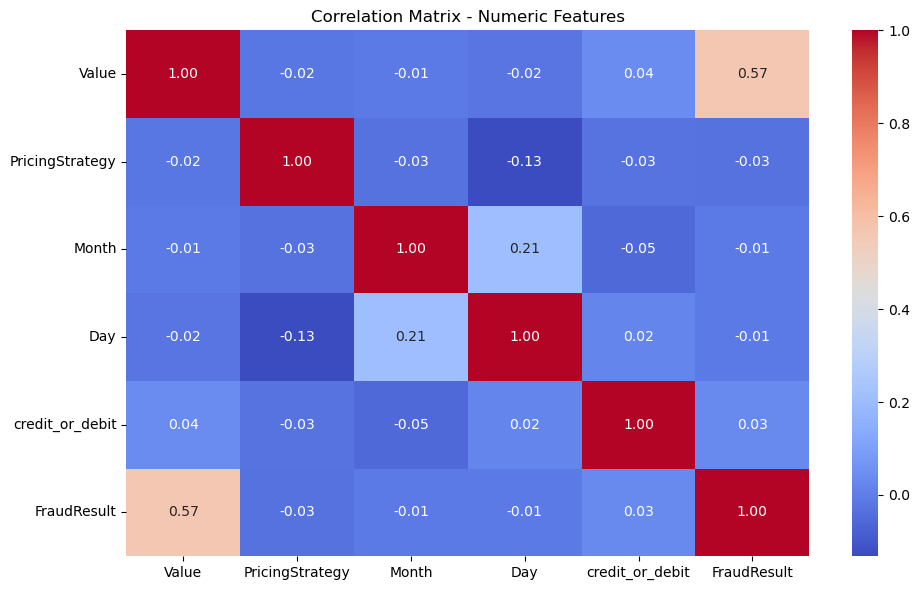

In [24]:
# This checks how correlated the features are
# Correlation among numeric features only

correlation_cols = [
    "Value",
    "PricingStrategy",
    "Month",
    "Day",
    "credit_or_debit",
    "FraudResult"
]

corr = df[correlation_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.show()

# Target Class Distribution

In [26]:
y.value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

In [27]:
fraud_sample = df[df["FraudResult"] == 1][[
    "ProviderId",
    "ProductId",
    "ProductCategory",
    "ChannelId",
    "Value",
    "PricingStrategy",
    "Month",
    "Day",
    "credit_or_debit"
]].head(1)

fraud_sample

,ProviderId,ProductId,ProductCategory,ChannelId,Value,PricingStrategy,Month,Day,credit_or_debit
131,ProviderId_3,ProductId_15,financial_services,ChannelId_3,700000,0,11,15,1


In [22]:
# Train- Test- Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=32,
    stratify=y
)

In [24]:
# Identify categorical and numerical columns
categorical_cols = x_train.select_dtypes(
    include=["object", "string"]
).columns

numerical_cols = x_train.select_dtypes(
    include=["number"]
).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']
Numerical columns: ['Value', 'PricingStrategy', 'Month', 'Day', 'credit_or_debit']


In [60]:
df[["ProviderId", "ProductId", "ProductCategory", "ChannelId"]].dtypes


ProviderId         str
ProductId          str
ProductCategory    str
ChannelId          str
dtype: object

In [30]:
x_train = x_train.astype({
    col: "object" for col in categorical_cols
})

x_test = x_test.astype({
    col: "object" for col in categorical_cols
})

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [34]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.sparse import hstack

# Explicitly define the categorical columns
categorical_cols = [
    "ProviderId",
    "ProductId",
    "ProductCategory",
    "ChannelId"
]

# Everything else is numerical
numerical_cols = [
    col for col in x_train.columns
    if col not in categorical_cols
]

# Make categorical columns standard Python objects
x_train_cat = x_train[categorical_cols].astype(str)
x_test_cat = x_test[categorical_cols].astype(str)

# One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown="ignore")

x_train_cat_encoded = encoder.fit_transform(x_train_cat)
x_test_cat_encoded = encoder.transform(x_test_cat)

# Scale numerical features
scaler = StandardScaler()

x_train_num_scaled = scaler.fit_transform(x_train[numerical_cols])
x_test_num_scaled = scaler.transform(x_test[numerical_cols])

# Combine categorical and numerical features
x_train_processed = hstack([
    x_train_num_scaled,
    x_train_cat_encoded
])

x_test_processed = hstack([
    x_test_num_scaled,
    x_test_cat_encoded
])

print("Training shape:", x_train_processed.shape)
print("Test shape:", x_test_processed.shape)

Training shape: (76529, 47)
Test shape: (19133, 47)


In [35]:
x_train_processed

<COOrdinate sparse matrix of dtype 'float64'
	with 688761 stored elements and shape (76529, 47)>

In [37]:
x_test_processed

<COOrdinate sparse matrix of dtype 'float64'
	with 172197 stored elements and shape (19133, 47)>

In [42]:
x_train_scaled = Scaler.fit_transform(x_train)
x_test_scaled = Scaler.transform(x_test)

# Training

In [38]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=32
)

log_model.fit(x_train_processed, y_train)

log_pred = log_model.predict(x_test_processed)

In [39]:
log_model.fit(x_train_processed, y_train)
log_pred = log_model.predict(x_test_processed)

In [40]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print("\nClassification Report:")
print(classification_report(y_test, log_pred, digits=4))

Confusion Matrix:
[[18998    96]
 [    0    39]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9950    0.9975     19094
           1     0.2889    1.0000    0.4483        39

    accuracy                         0.9950     19133
   macro avg     0.6444    0.9975    0.7229     19133
weighted avg     0.9986    0.9950    0.9964     19133



# Acurracy
 Accuracy score ranges from 0 to 1
 
 The percentage of total predictions the model got right
 
 accuracy = correct predictions/total predictions

# Confusion Matrix
This is a table used to describe the performance of a classification model by showing were it got things right and wrong

In [42]:
from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(y_test, log_pred)

print(log_cm)

[[18998    96]
 [    0    39]]


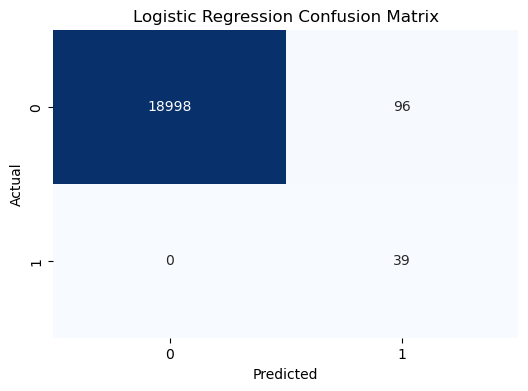

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    log_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Precision = TP/(TP+FP)

Of all transactions predicted as fraud, how many are actually fraud


Recall = TP/(TP + FN)

Of all fraudulent transactions, how many did the model catch?

F1-Score

Harmonic mean of precision and recall

This is the best metric for imbalanced datasets

# XGBoost MODEL

In [44]:
neg, pos = y_train.value_counts()

scale_pos_weight = neg / pos

print(scale_pos_weight)

495.9415584415584


In [45]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=32,
    eval_metric="logloss"
)

In [46]:
xgb_model.fit(x_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
xgb_pred = xgb_model.predict(x_test_processed)

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, digits=4))

Confusion Matrix:
[[19049    45]
 [    9    30]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9976    0.9986     19094
           1     0.4000    0.7692    0.5263        39

    accuracy                         0.9972     19133
   macro avg     0.6998    0.8834    0.7625     19133
weighted avg     0.9983    0.9972    0.9976     19133



# Random Forest Model

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=32,
    n_jobs=-1
)

In [50]:
rf_model.fit(x_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=32)

In [51]:
rf_pred = rf_model.predict(x_test_processed)

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, digits=4))

Confusion Matrix:
[[19082    12]
 [   10    29]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9994    0.9994     19094
           1     0.7073    0.7436    0.7250        39

    accuracy                         0.9989     19133
   macro avg     0.8534    0.8715    0.8622     19133
weighted avg     0.9989    0.9989    0.9989     19133



# ROC Curve
Reciever Operating Characteristic

In [53]:
rf_prob = rf_model.predict_proba(x_test_processed)[:, 1]

# AUC Score
Area under ROC Curve

In [54]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9996018349165935


Insight; From the result 0.9996 the model is strong ranking fraudulent transactions above legitimate ones on this test set

In [55]:
log_prob = log_model.predict_proba(x_test_processed)[:, 1]

log_auc = roc_auc_score(y_test, log_prob)

print("Logistic Regression ROC-AUC:", log_auc)

Logistic Regression ROC-AUC: 0.9994326315421947


In [56]:
xgb_prob = xgb_model.predict_proba(x_test_processed)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.9983549671933457


In [57]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "Random Forest"],
    "Fraud Precision": [0.2889, 0.4000, 0.7073],
    "Fraud Recall": [1.0000, 0.7692, 0.7436],
    "Fraud F1": [0.4483, 0.5263, 0.7250],
    "Accuracy": [0.9950, 0.9972, 0.9989],
    "ROC-AUC": [0.99943, 0.998354, 0.999602]
})

comparison

,Model,Fraud Precision,Fraud Recall,Fraud F1,Accuracy,ROC-AUC
0,Logistic Regression,0.2889,1.0000,0.4483,0.9950,0.999430
1,XGBoost,0.4000,0.7692,0.5263,0.9972,0.998354
2,Random Forest,0.7073,0.7436,0.7250,0.9989,0.999602


In [58]:
log_prob
xgb_prob
rf_prob

array([0., 0., 0., ..., 0., 0., 0.], shape=(19133,))

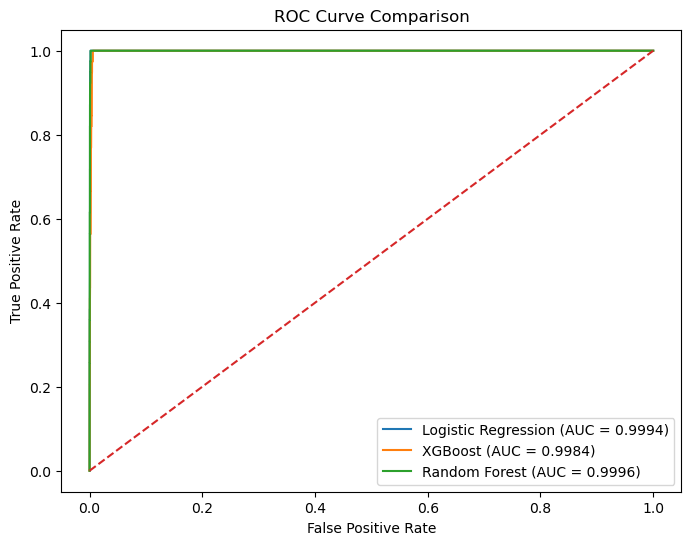

In [59]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.4f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.4f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# Feature Importance

In [60]:
encoded_cat_names = encoder.get_feature_names_out(categorical_cols)

feature_names = list(numerical_cols) + list(encoded_cat_names)

print("Number of feature names:", len(feature_names))

Number of feature names: 47


In [61]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
0,Value,0.493425
17,ProductId_ProductId_15,0.087940
10,ProviderId_ProviderId_6,0.047142
3,Day,0.041554
34,ProductCategory_airtime,0.041263
8,ProviderId_ProviderId_4,0.034333
30,ProductId_ProductId_6,0.031303
4,credit_or_debit,0.028394
36,ProductCategory_financial_services,0.027711
44,ChannelId_ChannelId_2,0.025049


In [62]:
df.groupby("FraudResult")["Value"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
FraudResult,,,,,,,,
0,95469.0,6763.23,39994.84,2.0,250.0,1000.0,5000.0,2400000.0
1,193.0,1561819.54,2081227.30,500.0,500000.0,650000.0,2000000.0,9880000.0


In [63]:
df[df["FraudResult"] == 1]["Value"].sort_values().head(20)

68888       500
68918      1005
71689     30000
69570     50000
70492     50000
69568    100000
70253    100000
71246    100000
70051    100000
70218    100000
69563    100000
70495    100000
70529    100000
70491    100000
73829    200000
69746    200000
73830    200000
70047    200000
69599    300000
68261    400000
Name: Value, dtype: int64

In [64]:
import pickle

with open("fraud_model_fixed.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [65]:
with open("fraud_encoder_fixed.pkl", "wb") as file:
    pickle.dump(encoder, file)

In [66]:
with open("fraud_scaler_fixed.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [67]:
feature_info = {
    "categorical_cols": list(categorical_cols),
    "numerical_cols": list(numerical_cols)
}

with open("fraud_feature_info_fixed.pkl", "wb") as file:
    pickle.dump(feature_info, file)

In [69]:
with open("fraud_model_fixed.pkl", "rb") as file:
    test_model = pickle.load(file)

with open("fraud_encoder_fixed.pkl", "rb") as file:
    test_encoder = pickle.load(file)

with open("fraud_scaler_fixed.pkl", "rb") as file:
    test_scaler = pickle.load(file)

with open("fraud_feature_info_fixed.pkl", "rb") as file:
    test_feature_info = pickle.load(file)

print("All saved files loaded successfully.")
print(test_feature_info)

All saved files loaded successfully.
{'categorical_cols': ['ProviderId', 'ProductId', 'ProductCategory', 'ChannelId'], 'numerical_cols': ['Value', 'PricingStrategy', 'Month', 'Day', 'credit_or_debit']}
